In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [8]:
def f(w):
    """
    目标函数: f(w1, w2) = 0.1*w1^2 + 2*w2^2
    w: torch.tensor, shape=(2,)
    """
    return 0.1 * w[0]**2 + 2 * w[1]**2

# adagrad 算法
定义历史累计梯度$G_t$ 参数为$w$ 学习率 $\eta$ 

累计梯度计算公式如下：
$$G_t = G_{t-1} + （\nabla f(w_t))^2$$

参数更新公式如下:
$$w_t = w_{t-1} - \frac{\eta}{\sqrt{G_t}}\nabla f(w_t) $$

In [9]:
def adagrad_optimization(f, w_init, learning_rate=0.1, epsilon=1e-8, num_iterations=1000):
    """
    使用Adagrad优化算法对函数f进行优化。
    参数:
        f: 可计算标量损失的函数, 输入为w (torch.tensor)
        w_init: 初始参数 (torch.tensor), requires_grad=True
        learning_rate: 学习率
        epsilon: 防止除0的平滑项
        num_iterations: 迭代步数

    返回:
        w_history: 优化过程中w的轨迹(list)，元素为(w1, w2)
        w_final: 最终的参数值
        f_final: 最终的函数值
    """
    w = w_init.clone().detach().requires_grad_(True)
    grad_squared_sum = torch.zeros_like(w)
    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad
        
        grad_squared_sum += grad * grad
        
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(grad_squared_sum) + epsilon)) * grad
        
        w_history.append((w[0].item(), w[1].item()))
    
    return w_history, w.detach(), f(w).item()

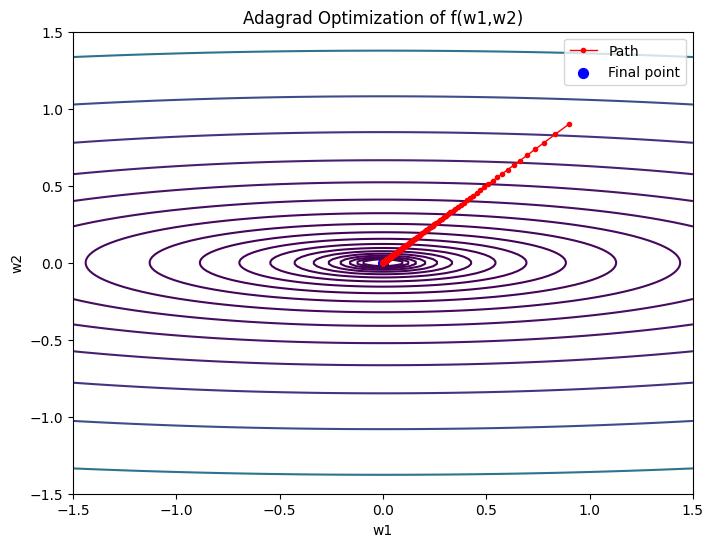

Final parameters: [8.000032e-15 7.999917e-15]
Final function value: 1.3439738597629322e-28


In [10]:
def plot_contour_and_trajectory(f, w_history, title='Optimization trajectory'):
    """
    绘制给定函数f的等高线以及优化过程w_history的参数轨迹。

    参数:
        f: 目标函数，输入为torch.tensor([w1, w2])
        w_history: 优化过程中的参数轨迹(list)，元素为(w1, w2)
        title: 图像标题
    """
    w_history = np.array(w_history)
    
    # 创建等高线图数据网格
    w1_vals = np.linspace(-1.5, 1.5, 200)
    w2_vals = np.linspace(-1.5, 1.5, 200)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    # 计算网格上函数值
    F = 0.1 * W1**2 + 2 * W2**2

    # 绘制等高线
    fig, ax = plt.subplots(figsize=(8, 6))
    contour_levels = np.logspace(-3, 1, 20)
    ax.contour(W1, W2, F, levels=contour_levels, cmap='viridis')

    # 绘制轨迹
    ax.plot(w_history[:,0], w_history[:,1], color='r', marker='o', markersize=3, linewidth=1, label='Path')
    # 标记最终点
    ax.scatter(w_history[-1,0], w_history[-1,1], color='blue', s=50, label='Final point')

    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(title)
    ax.legend()
    plt.show()

# ------------------主代码------------------
if __name__ == "__main__":
    # 初始点
    w_init = torch.tensor([1.0, 1.0], requires_grad=True)
    
    # 使用Adagrad进行优化
    w_history, w_final, f_final = adagrad_optimization(f, w_init, learning_rate=0.1, epsilon=1e-8, num_iterations=1000)
    
    # 可视化优化过程
    plot_contour_and_trajectory(f, w_history, title='Adagrad Optimization of f(w1,w2)')

    # 打印最终结果
    print("Final parameters:", w_final.numpy())
    print("Final function value:", f_final)


## RMSProp 算法 (Root Mean Square Propagation)

对于Adagrad算法 给历史梯度和当前梯度求和加上了权重

定义历加权移动平均梯度平方项 $E(G^2)$参数为$w$ 学习率 $\eta$  权重 $p ∈[0,1)$

加权移动平均梯度平方项公式计算如下:

$$E(G^2_t) = pE(G^2_{t-1}) + (1-p)(\nabla f(w_t))^2$$
参数更新方式如下:
$$w_t = w_{t-1} - \frac{\eta}{E(G^2_{t})}\nabla f(w)$$



In [11]:
def rmsprop_optimization(f, w_init, learning_rate=0.01, rho=0.9, epsilon=1e-8, num_iterations=1000):
    """
    使用RMSProp优化算法对函数f进行优化。
    参数:
        f: 可计算标量损失的函数, 输入为w (torch.tensor)
        w_init: 初始参数 (torch.tensor), requires_grad=True
        learning_rate: 学习率 η
        rho: 指数加权移动平均的衰减因子
        epsilon: 防止除0的平滑项
        num_iterations: 迭代步数

    返回:
        w_history: 优化过程中w的轨迹(list)，元素为(w1, w2)
        w_final: 最终的参数值
        f_final: 最终的函数值
    """
    w = w_init.clone().detach().requires_grad_(True)
    # E[g^2] 初始化为0
    Eg2 = torch.zeros_like(w)
    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad
        
        # 更新Eg2: E[g^2]_t = rho * E[g^2]_{t-1} + (1-rho)*g^2
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(Eg2) + epsilon)) * grad
        
        w_history.append((w[0].item(), w[1].item()))
    
    return w_history, w.detach(), f(w).item()


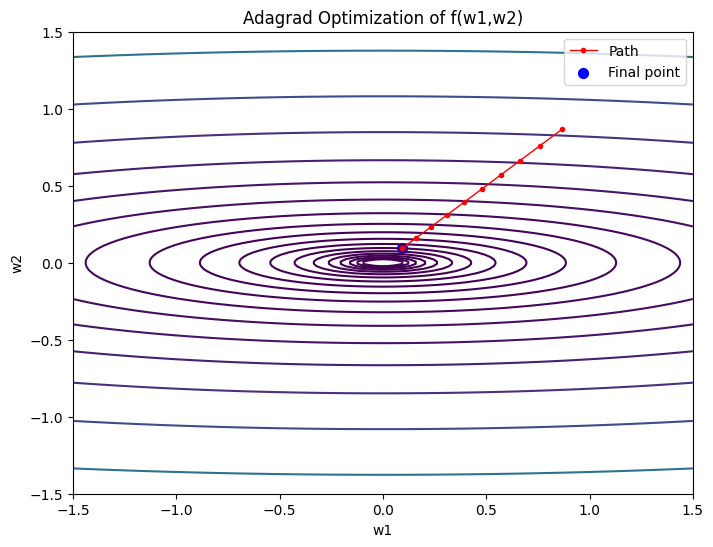

Final parameters: [0.09332753 0.09332746]
Final function value: 0.018291033804416656


In [27]:
if __name__ == "__main__":
    # 初始点
    w_init = torch.tensor([1.0, 1.0], requires_grad=True)
    
    # 使用Adagrad进行优化
    w_history, w_final, f_final = rmsprop_optimization(f, w_init, learning_rate=0.1,rho=0.45, epsilon=1e-8, num_iterations=10)
    
    # 可视化优化过程
    plot_contour_and_trajectory(f, w_history, title='Adagrad Optimization of f(w1,w2)')

    # 打印最终结果
    print("Final parameters:", w_final.numpy())
    print("Final function value:", f_final)

## AdaDelta 算法

AdaDelta 还维护参数更新量（Δw）的平方期望值，从而自适应地调节更新步幅，而无需明确设置全局学习率 
𝜂。

定义历加权移动平均梯度平方项 $E(G^2)$参数为$w$   权重 $p ∈[0,1)$

加权移动平均梯度平方项公式计算如下:

$$E(G^2_t) = pE(G^2_{t-1}) + (1-p)(\nabla f(w_t))^2$$

利用前一次的更新量的期望来调节本次的更新步幅

 $$\nabla w_t = \frac{\sqrt{E[\nabla w^2_{t-1}]}}{\sqrt{E[ G^2_{t-1}]}}G_{t} $$
更新参数

$$w_t = w_{t-1} + \nabla w_t$$

跟新$\nabla w$期望的平方

$$ E[\nabla w^2_t] = p E[\nabla w^2_{t-1}] + (1-p) \nabla w^2_{t} $$

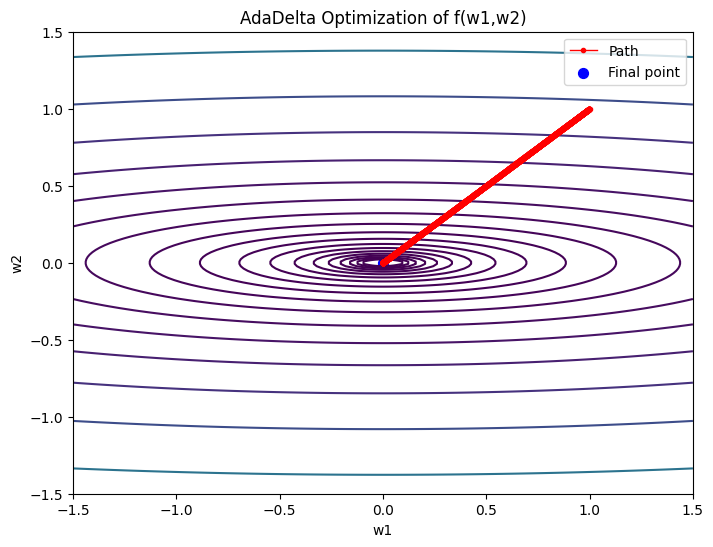

Final parameters: [ 2.8025969e-45 -3.8826754e-03]
Final function value: 3.0150336897349916e-05


In [31]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def f(w):
    """
    目标函数: f(w1, w2) = 0.1*w1^2 + 2*w2^2
    w: torch.tensor, shape=(2,)
    """
    return 0.1 * w[0]**2 + 2 * w[1]**2

def adadelta_optimization(f, w_init, rho=0.9, epsilon=1e-8, num_iterations=1000):
    """
    使用AdaDelta优化算法对函数f进行优化。
    参数:
        f: 可计算标量损失的函数, 输入为w (torch.tensor)
        w_init: 初始参数 (torch.tensor), requires_grad=True
        rho: 指数加权平均的衰减因子
        epsilon: 防止除0的平滑项
        num_iterations: 迭代步数

    返回:
        w_history: 优化过程中w的轨迹(list)，元素为(w1, w2)
        w_final: 最终的参数值
        f_final: 最终的函数值
    """
    w = w_init.clone().detach().requires_grad_(True)
    # E[g^2] 和 E[Δw^2] 初始化为0
    Eg2 = torch.zeros_like(w)
    Edw2 = torch.zeros_like(w)

    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad
        
        # 更新 Eg2: E[g^2]_t = rho * E[g^2]_{t-1} + (1-rho)*g_t^2
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        
        # 根据 AdaDelta 更新公式计算 Δw
        # Δw_t = - ( sqrt(E[Δw^2]_{t-1} + epsilon) / sqrt(E[g^2]_t + epsilon) ) * g_t
        delta_w = -(torch.sqrt(Edw2 + epsilon) / torch.sqrt(Eg2 + epsilon)) * grad
        
        # 更新参数
        with torch.no_grad():
            w += delta_w
        
        # 更新 E[Δw^2]: E[Δw^2]_t = rho * E[Δw^2]_{t-1} + (1-rho)*(Δw_t^2)
        Edw2 = rho * Edw2 + (1 - rho)*(delta_w * delta_w)
        
        w_history.append((w[0].item(), w[1].item()))
    
    return w_history, w.detach(), f(w).item()

def plot_contour_and_trajectory(f, w_history, title='Optimization trajectory'):
    """
    绘制给定函数f的等高线以及优化过程w_history的参数轨迹。
    """
    w_history = np.array(w_history)
    
    # 创建等高线图数据网格
    w1_vals = np.linspace(-1.5, 1.5, 200)
    w2_vals = np.linspace(-1.5, 1.5, 200)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    # 计算网格上函数值
    F = 0.1 * W1**2 + 2 * W2**2

    # 绘制等高线
    fig, ax = plt.subplots(figsize=(8, 6))
    contour_levels = np.logspace(-3, 1, 20)
    ax.contour(W1, W2, F, levels=contour_levels, cmap='viridis')

    # 绘制轨迹
    ax.plot(w_history[:,0], w_history[:,1], color='r', marker='o', markersize=3, linewidth=1, label='Path')
    # 标记最终点
    ax.scatter(w_history[-1,0], w_history[-1,1], color='blue', s=50, label='Final point')

    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(title)
    ax.legend()
    plt.show()

# ------------------主代码------------------
if __name__ == "__main__":
    # 初始点
    w_init = torch.tensor([1.0, 1.0], requires_grad=True)
    
    # 使用AdaDelta进行优化
    w_history, w_final, f_final = adadelta_optimization(f, w_init, rho=0.9, epsilon=1e-8, num_iterations=10000)
    
    # 可视化优化过程
    plot_contour_and_trajectory(f, w_history, title='AdaDelta Optimization of f(w1,w2)')

    # 打印最终结果
    print("Final parameters:", w_final.numpy())
    print("Final function value:", f_final)


## SGD with momentum 算法

设动量因子为 $p$一般设为0.9 习率为 $\eta$ 速度项为 $v$

首先更新速度项

$$ v_t = p v_{t-1} + \eta \nabla f(w_t)$$

更新参数

$$ w_t = w_{t-1} - v_t$$

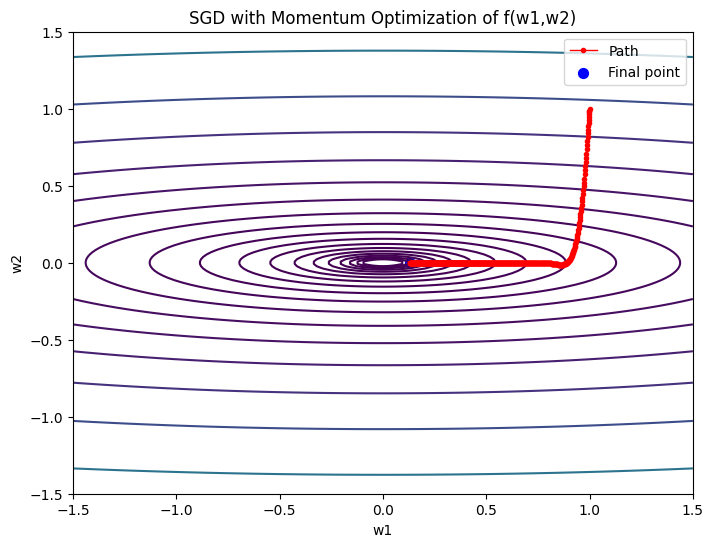

Final parameters: [1.3257837e-01 1.7271289e-23]
Final function value: 0.0017577024409547448


In [34]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def f(w):
    """
    目标函数: f(w1, w2) = 0.1*w1^2 + 2*w2^2
    w: torch.tensor, shape=(2,)
    """
    return 0.1 * w[0]**2 + 2 * w[1]**2

def sgd_momentum_optimization(f, w_init, learning_rate=0.01, momentum=0.9, num_iterations=1000):
    """
    使用SGD with Momentum优化算法对函数f进行优化。
    参数:
        f: 可计算标量损失的函数, 输入为w (torch.tensor)
        w_init: 初始参数 (torch.tensor), requires_grad=True
        learning_rate: 学习率 η
        momentum: 动量因子 μ
        num_iterations: 迭代步数

    返回:
        w_history: 优化过程中w的轨迹(list)，元素为(w1, w2)
        w_final: 最终的参数值
        f_final: 最终的函数值
    """
    w = w_init.clone().detach().requires_grad_(True)
    # v初始化为0
    v = torch.zeros_like(w)
    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad

        # 更新速度项: v_t = μ v_{t-1} + η g_t
        v = momentum * v + learning_rate * grad

        # 参数更新: w_t = w_{t-1} - v_t
        with torch.no_grad():
            w -= v

        w_history.append((w[0].item(), w[1].item()))
    
    return w_history, w.detach(), f(w).item()

def plot_contour_and_trajectory(f, w_history, title='Optimization trajectory'):
    """
    绘制给定函数f的等高线以及优化过程w_history的参数轨迹。
    """
    w_history = np.array(w_history)
    
    # 创建等高线图数据网格
    w1_vals = np.linspace(-1.5, 1.5, 200)
    w2_vals = np.linspace(-1.5, 1.5, 200)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    # 计算网格上函数值
    F = 0.1 * W1**2 + 2 * W2**2

    # 绘制等高线
    fig, ax = plt.subplots(figsize=(8, 6))
    contour_levels = np.logspace(-3, 1, 20)
    ax.contour(W1, W2, F, levels=contour_levels, cmap='viridis')

    # 绘制轨迹
    ax.plot(w_history[:,0], w_history[:,1], color='r', marker='o', markersize=3, linewidth=1, label='Path')
    # 标记最终点
    ax.scatter(w_history[-1,0], w_history[-1,1], color='blue', s=50, label='Final point')

    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(title)
    ax.legend()
    plt.show()

# ------------------主代码------------------
if __name__ == "__main__":
    # 初始点
    w_init = torch.tensor([1.0, 1.0], requires_grad=True)
    
    # 使用SGD with Momentum进行优化
    w_history, w_final, f_final = sgd_momentum_optimization(f, w_init, learning_rate=0.001, momentum=0.9, num_iterations=1000)
    
    # 可视化优化过程
    plot_contour_and_trajectory(f, w_history, title='SGD with Momentum Optimization of f(w1,w2)')

    # 打印最终结果
    print("Final parameters:", w_final.numpy())
    print("Final function value:", f_final)


## Adam 算法

首先对梯度 $G_t$进行一阶矩估计（动量） 和二阶矩估计（梯度平方）

$$G_t = \nabla f(w_t)$$
$$ v_t = \beta_1 v_{t-1} + (1-\beta_1) \nabla f(w_t)$$
$$ m_t = \beta_2 m_{t-1} + (1-\beta_2) \nabla f(w_t)^2$$

对一阶矩和二阶矩进行修正

$$ v_t =  \frac{v_t}{1 - \beta_1^t}  $$$$m_t =  \frac{m_t}{1 - \beta_2^t} $$

其中 $\beta_1^t = \prod \limits_{t=0}^t \beta_1^t$,$\beta_2^t = \prod \limits_{t=0}^t \beta_2^t$

跟新参数

$$w_t = w_{t-1} - \frac{\eta v_t}{\sqrt{m_t}} $$

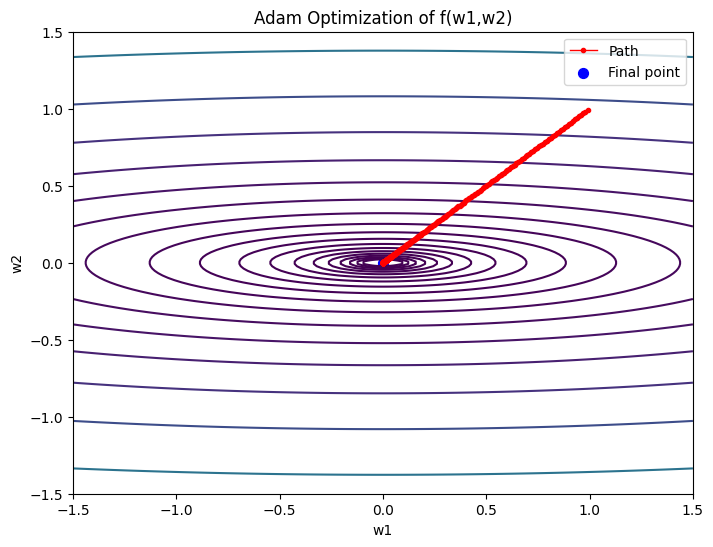

Final parameters: [-1.8106148e-21 -1.8110205e-21]
Final function value: 6.888783250620801e-42


In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def f(w):
    """
    目标函数: f(w1, w2) = 0.1*w1^2 + 2*w2^2
    w: torch.tensor, shape=(2,)
    """
    return 0.1 * w[0]**2 + 2 * w[1]**2

def adam_optimization(f, w_init, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, num_iterations=1000):
    """
    使用Adam优化算法对函数f进行优化。
    参数:
        f: 可计算标量损失的函数, 输入为w (torch.tensor)
        w_init: 初始参数 (torch.tensor), requires_grad=True
        learning_rate: 学习率 η
        beta1: 一阶矩估计的衰减率
        beta2: 二阶矩估计的衰减率
        epsilon: 防止除0的平滑项
        num_iterations: 迭代步数

    返回:
        w_history: 优化过程中w的轨迹(list)，元素为(w1, w2)
        w_final: 最终的参数值
        f_final: 最终的函数值
    """
    w = w_init.clone().detach().requires_grad_(True)
    m = torch.zeros_like(w)  # 一阶矩初始化
    v = torch.zeros_like(w)  # 二阶矩初始化
    w_history = []

    for t in range(1, num_iterations + 1):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad

        # 更新一阶矩、二阶矩
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad * grad)

        # 偏差校正
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        # 参数更新
        with torch.no_grad():
            w -= learning_rate * m_hat / (torch.sqrt(v_hat) + epsilon)

        w_history.append((w[0].item(), w[1].item()))
    
    return w_history, w.detach(), f(w).item()

def plot_contour_and_trajectory(f, w_history, title='Optimization trajectory'):
    """
    绘制给定函数f的等高线以及优化过程w_history的参数轨迹。
    """
    w_history = np.array(w_history)
    
    # 创建等高线图数据网格
    w1_vals = np.linspace(-1.5, 1.5, 200)
    w2_vals = np.linspace(-1.5, 1.5, 200)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    # 计算网格上函数值
    F = 0.1 * W1**2 + 2 * W2**2

    # 绘制等高线
    fig, ax = plt.subplots(figsize=(8, 6))
    contour_levels = np.logspace(-3, 1, 20)
    ax.contour(W1, W2, F, levels=contour_levels, cmap='viridis')

    # 绘制轨迹
    ax.plot(w_history[:,0], w_history[:,1], color='r', marker='o', markersize=3, linewidth=1, label='Path')
    # 标记最终点
    ax.scatter(w_history[-1,0], w_history[-1,1], color='blue', s=50, label='Final point')

    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(title)
    ax.legend()
    plt.show()

# ------------------主代码------------------
if __name__ == "__main__":
    # 初始点
    w_init = torch.tensor([1.0, 1.0], requires_grad=True)
    
    # 使用Adam进行优化
    w_history, w_final, f_final = adam_optimization(f, w_init, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, num_iterations=1000)
    
    # 可视化优化过程
    plot_contour_and_trajectory(f, w_history, title='Adam Optimization of f(w1,w2)')

    # 打印最终结果
    print("Final parameters:", w_final.numpy())
    print("Final function value:", f_final)


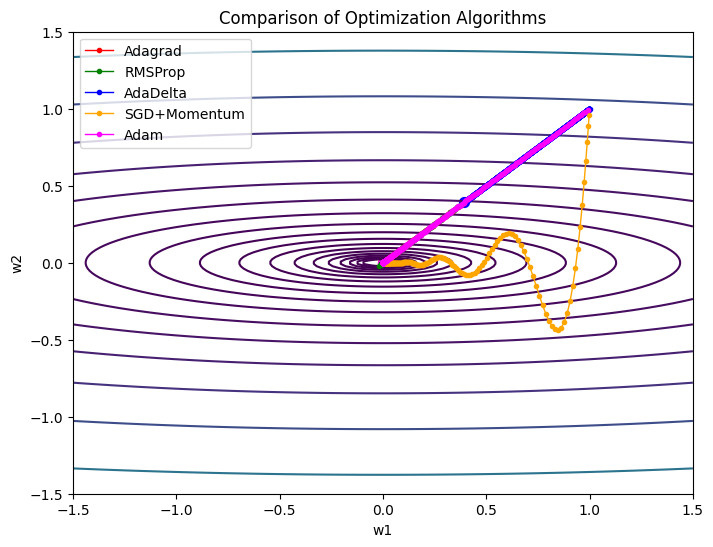

Adagrad: final w = [8.000032e-15 7.999917e-15] f(w) = 1.3439738597629322e-28
RMSProp: final w = [0.00499996 0.005     ] f(w) = 5.2499890443868935e-05
AdaDelta: final w = [0.3945401 0.3945369] f(w) = 0.3268849551677704
SGD+Momentum: final w = [ 3.3013969e-12 -1.0138247e-23] f(w) = 1.0899221755200114e-24
Adam: final w = [-1.8106148e-21 -1.8110205e-21] f(w) = 6.888783250620801e-42


In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 假设这些函数都已定义：
# f(w), adagrad_optimization, rmsprop_optimization, adadelta_optimization, sgd_momentum_optimization, adam_optimization

def f(w):
    return 0.1 * w[0]**2 + 2 * w[1]**2

def plot_contour(f, ax):
    # 创建等高线图数据网格
    w1_vals = np.linspace(-1.5, 1.5, 200)
    w2_vals = np.linspace(-1.5, 1.5, 200)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    # 计算网格上函数值
    F = 0.1 * W1**2 + 2 * W2**2

    # 绘制等高线
    contour_levels = np.logspace(-3, 1, 20)
    ax.contour(W1, W2, F, levels=contour_levels, cmap='viridis')
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title('Comparison of Optimization Algorithms')

def adagrad_optimization(f, w_init, learning_rate=0.1, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    grad_squared_sum = torch.zeros_like(w)
    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        loss = f(w)
        loss.backward()
        grad = w.grad
        grad_squared_sum += grad * grad
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(grad_squared_sum) + epsilon)) * grad
        w_history.append((w[0].item(), w[1].item()))

    return w_history, w.detach(), f(w).item()

def rmsprop_optimization(f, w_init, learning_rate=0.01, rho=0.9, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    Eg2 = torch.zeros_like(w)
    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(Eg2) + epsilon)) * grad
        w_history.append((w[0].item(), w[1].item()))
    return w_history, w.detach(), f(w).item()

def adadelta_optimization(f, w_init, rho=0.9, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    Eg2 = torch.zeros_like(w)
    Edw2 = torch.zeros_like(w)
    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        delta_w = -(torch.sqrt(Edw2 + epsilon) / torch.sqrt(Eg2 + epsilon)) * grad
        with torch.no_grad():
            w += delta_w
        Edw2 = rho * Edw2 + (1 - rho) * (delta_w * delta_w)
        w_history.append((w[0].item(), w[1].item()))
    return w_history, w.detach(), f(w).item()

def sgd_momentum_optimization(f, w_init, learning_rate=0.01, momentum=0.9, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    v = torch.zeros_like(w)
    w_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        loss = f(w)
        loss.backward()
        grad = w.grad

        v = momentum * v + learning_rate * grad
        with torch.no_grad():
            w -= v
        w_history.append((w[0].item(), w[1].item()))
    return w_history, w.detach(), f(w).item()

def adam_optimization(f, w_init, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    m = torch.zeros_like(w)
    v = torch.zeros_like(w)
    w_history = []

    for t in range(1, num_iterations+1):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad * grad)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        with torch.no_grad():
            w -= learning_rate * m_hat / (torch.sqrt(v_hat) + epsilon)
        w_history.append((w[0].item(), w[1].item()))
    return w_history, w.detach(), f(w).item()

if __name__ == "__main__":
    w_init = torch.tensor([1.0, 1.0], requires_grad=True)
    num_iterations = 1000

    # 对比以上算法
    adagrad_path, adagrad_final, adagrad_val = adagrad_optimization(f, w_init, num_iterations=num_iterations)
    rmsprop_path, rmsprop_final, rmsprop_val = rmsprop_optimization(f, w_init, num_iterations=num_iterations)
    adadelta_path, adadelta_final, adadelta_val = adadelta_optimization(f, w_init, num_iterations=num_iterations)
    sgd_m_path, sgd_m_final, sgd_m_val = sgd_momentum_optimization(f, w_init, num_iterations=num_iterations)
    adam_path, adam_final, adam_val = adam_optimization(f, w_init, num_iterations=num_iterations)

    fig, ax = plt.subplots(figsize=(8,6))
    # 绘制等高线
    plot_contour(f, ax)

    # 绘制各优化算法的轨迹
    paths = [
        (adagrad_path, 'Adagrad'),
        (rmsprop_path, 'RMSProp'),
        (adadelta_path, 'AdaDelta'),
        (sgd_m_path, 'SGD+Momentum'),
        (adam_path, 'Adam')
    ]

    colors = ['red', 'green', 'blue', 'orange', 'magenta']
    for (path, name), c in zip(paths, colors):
        p = np.array(path)
        ax.plot(p[:,0], p[:,1], color=c, marker='o', markersize=3, linewidth=1, label=name)
        ax.scatter(p[-1,0], p[-1,1], color=c, s=50) # 标记最终点

    ax.legend()
    plt.show()

    # 打印最终结果
    print("Adagrad: final w =", adagrad_final.numpy(), "f(w) =", adagrad_val)
    print("RMSProp: final w =", rmsprop_final.numpy(), "f(w) =", rmsprop_val)
    print("AdaDelta: final w =", adadelta_final.numpy(), "f(w) =", adadelta_val)
    print("SGD+Momentum: final w =", sgd_m_final.numpy(), "f(w) =", sgd_m_val)
    print("Adam: final w =", adam_final.numpy(), "f(w) =", adam_val)


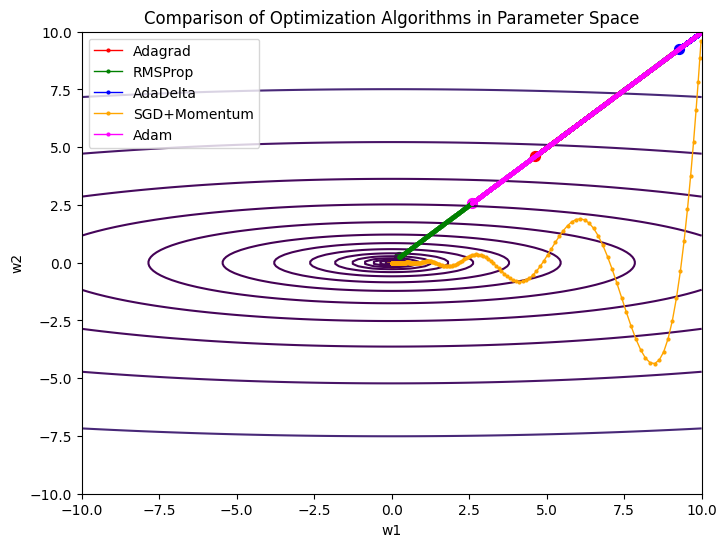

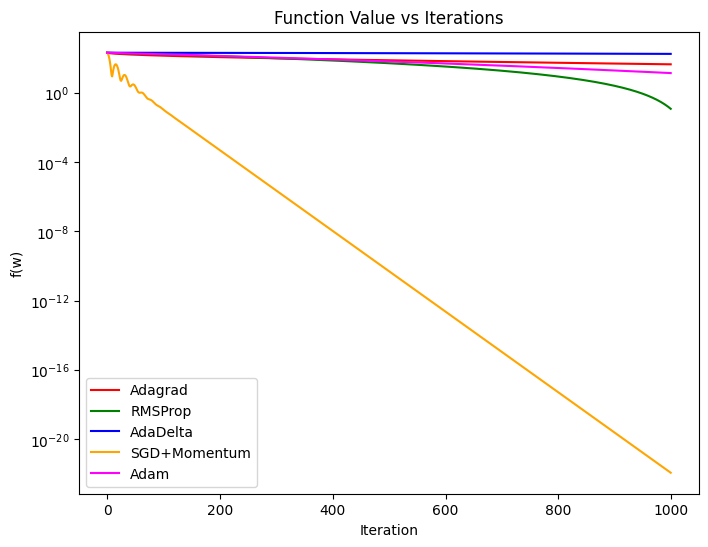

Adagrad: final w = [4.625368 4.625369] f(w) = 44.92748260498047
RMSProp: final w = [0.23256722 0.23256698] f(w) = 0.11358354985713959
AdaDelta: final w = [9.256044 9.256044] f(w) = 179.9161376953125
SGD+Momentum: final w = [ 3.30140255e-11 -1.01382397e-22] f(w) = 1.0899259462751383e-22
Adam: final w = [2.5766568 2.5766559] f(w) = 13.94222640991211


In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def f(w):
    return 0.1 * w[0]**2 + 2 * w[1]**2

def adagrad_optimization(f, w_init, learning_rate=0.1, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    grad_squared_sum = torch.zeros_like(w)
    w_history = []
    f_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        loss = f(w)
        loss.backward()
        grad = w.grad
        grad_squared_sum += grad * grad
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(grad_squared_sum) + epsilon)) * grad
        w_history.append((w[0].item(), w[1].item()))
        f_history.append(loss.item())

    return w_history, w.detach(), f(w).item(), f_history

def rmsprop_optimization(f, w_init, learning_rate=0.01, rho=0.9, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    Eg2 = torch.zeros_like(w)
    w_history = []
    f_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()

        loss = f(w)
        loss.backward()
        grad = w.grad
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(Eg2) + epsilon)) * grad
        w_history.append((w[0].item(), w[1].item()))
        f_history.append(loss.item())
    return w_history, w.detach(), f(w).item(), f_history

def adadelta_optimization(f, w_init, rho=0.9, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    Eg2 = torch.zeros_like(w)
    Edw2 = torch.zeros_like(w)
    w_history = []
    f_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()

        loss = f(w)
        loss.backward()
        grad = w.grad
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        delta_w = -(torch.sqrt(Edw2 + epsilon) / torch.sqrt(Eg2 + epsilon)) * grad
        with torch.no_grad():
            w += delta_w
        Edw2 = rho * Edw2 + (1 - rho) * (delta_w * delta_w)
        w_history.append((w[0].item(), w[1].item()))
        f_history.append(loss.item())
    return w_history, w.detach(), f(w).item(), f_history

def sgd_momentum_optimization(f, w_init, learning_rate=0.01, momentum=0.9, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    v = torch.zeros_like(w)
    w_history = []
    f_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        loss = f(w)
        loss.backward()
        grad = w.grad

        v = momentum * v + learning_rate * grad
        with torch.no_grad():
            w -= v
        w_history.append((w[0].item(), w[1].item()))
        f_history.append(loss.item())
    return w_history, w.detach(), f(w).item(), f_history

def adam_optimization(f, w_init, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    m = torch.zeros_like(w)
    v = torch.zeros_like(w)
    w_history = []
    f_history = []

    for t in range(1, num_iterations+1):
        if w.grad is not None:
            w.grad.zero_()

        loss = f(w)
        loss.backward()
        grad = w.grad
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad * grad)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        with torch.no_grad():
            w -= learning_rate * m_hat / (torch.sqrt(v_hat) + epsilon)
        w_history.append((w[0].item(), w[1].item()))
        f_history.append(loss.item())
    return w_history, w.detach(), f(w).item(), f_history

def plot_contour(ax):
    w1_vals = np.linspace(-10, 10, 200)
    w2_vals = np.linspace(-10, 10, 200)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    F = 0.1 * W1**2 + 2 * W2**2
    contour_levels = np.logspace(-3, 3, 20)
    ax.contour(W1, W2, F, levels=contour_levels, cmap='viridis')
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title('Comparison of Optimization Algorithms in Parameter Space')

if __name__ == "__main__":
    w_init = torch.tensor([10.0, 10.0], requires_grad=True)
    num_iterations = 1000

    # 运行各算法
    adagrad_path, adagrad_final, adagrad_val, adagrad_fhist = adagrad_optimization(f, w_init, num_iterations=num_iterations)
    rmsprop_path, rmsprop_final, rmsprop_val, rmsprop_fhist = rmsprop_optimization(f, w_init, num_iterations=num_iterations)
    adadelta_path, adadelta_final, adadelta_val, adadelta_fhist = adadelta_optimization(f, w_init, num_iterations=num_iterations)
    sgd_m_path, sgd_m_final, sgd_m_val, sgd_m_fhist = sgd_momentum_optimization(f, w_init, num_iterations=num_iterations)
    adam_path, adam_final, adam_val, adam_fhist = adam_optimization(f, w_init, num_iterations=num_iterations)

    # 参数空间对比图
    fig, ax = plt.subplots(figsize=(8,6))
    plot_contour(ax)

    paths = [
        (adagrad_path, 'Adagrad'),
        (rmsprop_path, 'RMSProp'),
        (adadelta_path, 'AdaDelta'),
        (sgd_m_path, 'SGD+Momentum'),
        (adam_path, 'Adam')
    ]

    colors = ['red', 'green', 'blue', 'orange', 'magenta']
    for (path, name), c in zip(paths, colors):
        p = np.array(path)
        ax.plot(p[:,0], p[:,1], color=c, marker='o', markersize=2, linewidth=1, label=name)
        ax.scatter(p[-1,0], p[-1,1], color=c, s=50)

    ax.legend()
    plt.show()

    # 函数值收敛曲线对比图
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(adagrad_fhist, label='Adagrad', color='red')
    ax.plot(rmsprop_fhist, label='RMSProp', color='green')
    ax.plot(adadelta_fhist, label='AdaDelta', color='blue')
    ax.plot(sgd_m_fhist, label='SGD+Momentum', color='orange')
    ax.plot(adam_fhist, label='Adam', color='magenta')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('f(w)')
    ax.set_yscale('log')  # 使用对数尺度更好比较收敛
    ax.set_title('Function Value vs Iterations')
    ax.legend()
    plt.show()

    # 打印最终结果
    print("Adagrad: final w =", adagrad_final.numpy(), "f(w) =", adagrad_val)
    print("RMSProp: final w =", rmsprop_final.numpy(), "f(w) =", rmsprop_val)
    print("AdaDelta: final w =", adadelta_final.numpy(), "f(w) =", adadelta_val)
    print("SGD+Momentum: final w =", sgd_m_final.numpy(), "f(w) =", sgd_m_val)
    print("Adam: final w =", adam_final.numpy(), "f(w) =", adam_val)


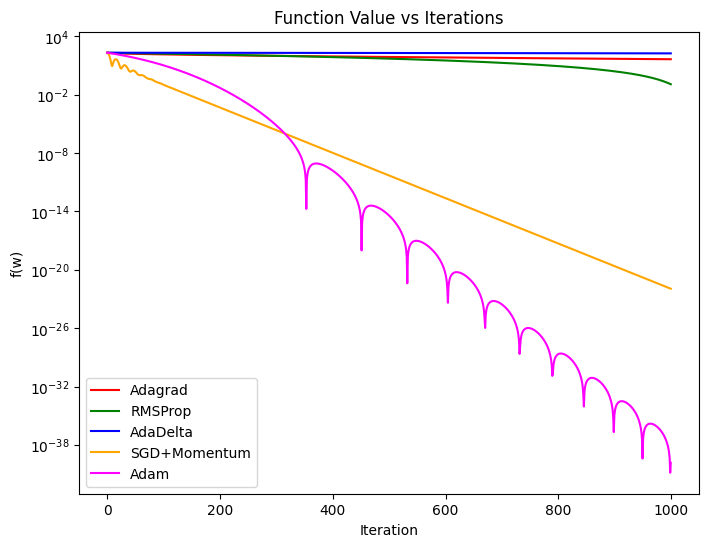

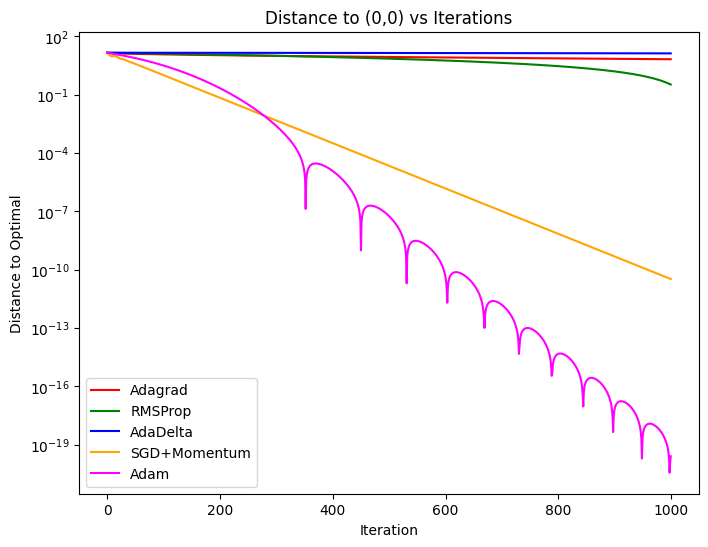

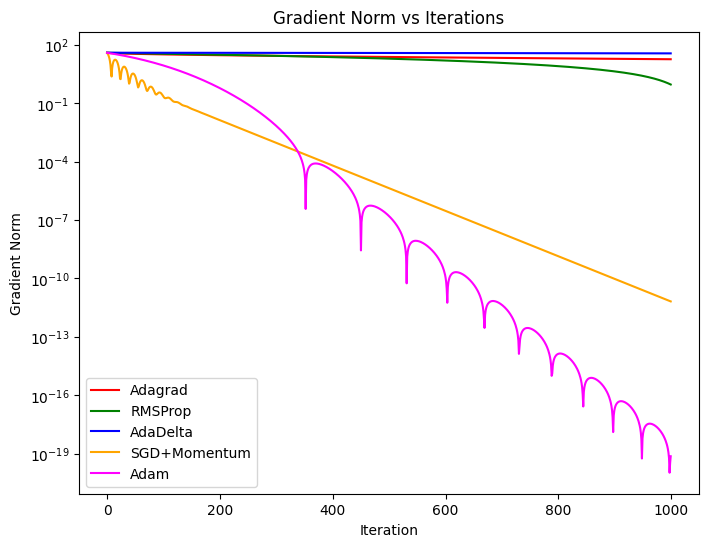

In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def f(w):
    return 0.1 * w[0]**2 + 2 * w[1]**2

def gradient(w):
    # 手动计算梯度: df/dw1 = 0.2*w1, df/dw2 = 4*w2
    grad_w1 = 0.2 * w[0]
    grad_w2 = 4.0 * w[1]
    return torch.tensor([grad_w1, grad_w2])

def adagrad_optimization(f, w_init, learning_rate=0.1, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    grad_squared_sum = torch.zeros_like(w)
    f_history = []
    dist_history = []
    grad_norm_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        loss = f(w)
        loss.backward()
        grad = w.grad
        grad_squared_sum += grad * grad
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(grad_squared_sum) + epsilon)) * grad
        
        f_history.append(loss.item())
        dist_history.append(torch.norm(w).item()) # 距离(0,0)
        g = gradient(w)
        grad_norm_history.append(torch.norm(g).item())
    return f_history, dist_history, grad_norm_history

def rmsprop_optimization(f, w_init, learning_rate=0.01, rho=0.9, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    Eg2 = torch.zeros_like(w)
    f_history = []
    dist_history = []
    grad_norm_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        loss = f(w)
        loss.backward()
        grad = w.grad
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        with torch.no_grad():
            w -= (learning_rate / (torch.sqrt(Eg2) + epsilon)) * grad
        
        f_history.append(loss.item())
        dist_history.append(torch.norm(w).item())
        g = gradient(w)
        grad_norm_history.append(torch.norm(g).item())
    return f_history, dist_history, grad_norm_history

def adadelta_optimization(f, w_init, rho=0.9, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    Eg2 = torch.zeros_like(w)
    Edw2 = torch.zeros_like(w)
    f_history = []
    dist_history = []
    grad_norm_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        
        loss = f(w)
        loss.backward()
        grad = w.grad
        Eg2 = rho * Eg2 + (1 - rho) * (grad * grad)
        delta_w = -(torch.sqrt(Edw2 + epsilon) / torch.sqrt(Eg2 + epsilon)) * grad
        with torch.no_grad():
            w += delta_w
        Edw2 = rho * Edw2 + (1 - rho) * (delta_w * delta_w)
        
        f_history.append(loss.item())
        dist_history.append(torch.norm(w).item())
        g = gradient(w)
        grad_norm_history.append(torch.norm(g).item())
    return f_history, dist_history, grad_norm_history

def sgd_momentum_optimization(f, w_init, learning_rate=0.01, momentum=0.9, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    v = torch.zeros_like(w)
    f_history = []
    dist_history = []
    grad_norm_history = []

    for i in range(num_iterations):
        if w.grad is not None:
            w.grad.zero_()
        loss = f(w)
        loss.backward()
        grad = w.grad

        v = momentum * v + learning_rate * grad
        with torch.no_grad():
            w -= v
        
        f_history.append(loss.item())
        dist_history.append(torch.norm(w).item())
        g = gradient(w)
        grad_norm_history.append(torch.norm(g).item())
    return f_history, dist_history, grad_norm_history

def adam_optimization(f, w_init, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, num_iterations=1000):
    w = w_init.clone().detach().requires_grad_(True)
    m = torch.zeros_like(w)
    v = torch.zeros_like(w)
    f_history = []
    dist_history = []
    grad_norm_history = []

    for t in range(1, num_iterations+1):
        if w.grad is not None:
            w.grad.zero_()

        loss = f(w)
        loss.backward()
        grad = w.grad
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad * grad)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        with torch.no_grad():
            w -= learning_rate * m_hat / (torch.sqrt(v_hat) + epsilon)
        
        f_history.append(loss.item())
        dist_history.append(torch.norm(w).item())
        g = gradient(w)
        grad_norm_history.append(torch.norm(g).item())
    return f_history, dist_history, grad_norm_history

if __name__ == "__main__":
    w_init = torch.tensor([10.0, 10.0], requires_grad=True)
    num_iterations = 1000

    # 获取各算法的指标数据
    ada_f, ada_dist, ada_gnorm = adagrad_optimization(f, w_init, num_iterations=num_iterations)
    rms_f, rms_dist, rms_gnorm = rmsprop_optimization(f, w_init, num_iterations=num_iterations)
    adaD_f, adaD_dist, adaD_gnorm = adadelta_optimization(f, w_init, num_iterations=num_iterations)
    sgd_f, sgd_dist, sgd_gnorm = sgd_momentum_optimization(f, w_init, num_iterations=num_iterations)
    adam_f, adam_dist, adam_gnorm = adam_optimization(f, w_init, num_iterations=num_iterations)

    # 函数值对比图（已是替代观测路径的一种指标）
    plt.figure(figsize=(8,6))
    plt.plot(ada_f, label='Adagrad', color='red')
    plt.plot(rms_f, label='RMSProp', color='green')
    plt.plot(adaD_f, label='AdaDelta', color='blue')
    plt.plot(sgd_f, label='SGD+Momentum', color='orange')
    plt.plot(adam_f, label='Adam', color='magenta')
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(w)')
    plt.title('Function Value vs Iterations')
    plt.legend()
    plt.show()

    # 参数距离最优点(0,0)的变化
    plt.figure(figsize=(8,6))
    plt.plot(ada_dist, label='Adagrad', color='red')
    plt.plot(rms_dist, label='RMSProp', color='green')
    plt.plot(adaD_dist, label='AdaDelta', color='blue')
    plt.plot(sgd_dist, label='SGD+Momentum', color='orange')
    plt.plot(adam_dist, label='Adam', color='magenta')
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Distance to Optimal')
    plt.title('Distance to (0,0) vs Iterations')
    plt.legend()
    plt.show()

    # 梯度范数变化
    plt.figure(figsize=(8,6))
    plt.plot(ada_gnorm, label='Adagrad', color='red')
    plt.plot(rms_gnorm, label='RMSProp', color='green')
    plt.plot(adaD_gnorm, label='AdaDelta', color='blue')
    plt.plot(sgd_gnorm, label='SGD+Momentum', color='orange')
    plt.plot(adam_gnorm, label='Adam', color='magenta')
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Gradient Norm')
    plt.title('Gradient Norm vs Iterations')
    plt.legend()
    plt.show()
